In [1]:
import sys,os,glob,copy
sys.path.append('../')
import numpy as np
from numpy.linalg import norm
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator,interp2d
import matplotlib as mpl
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown
from collections import OrderedDict
import pylhe
import glob
import pyslha

delphesDir = os.path.abspath("../../../MG5/Delphes/")
os.environ['ROOT_INCLUDE_PATH'] = os.path.join(delphesDir,"external")

import ROOT
import xml.etree.ElementTree as ET


ROOT.gSystem.Load(os.path.join(delphesDir,"libDelphes.so"))

ROOT.gInterpreter.Declare('#include "classes/SortableObject.h"')
ROOT.gInterpreter.Declare('#include "classes/DelphesClasses.h"')
ROOT.gInterpreter.Declare('#include "external/ExRootAnalysis/ExRootTreeReader.h"')

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.cm.get_cmap('RdYlBu')

Welcome to JupyROOT 6.26/10


/tmp/ipykernel_17994/3496676323.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('RdYlBu')


# Set Delphes output file

In [2]:
# inputFiles =  {'1j-full' : '/home/camila/MG5/DMsimp_t-S3D_uR_PhiPhiToJChiChi/Events/run_02/tag_1_delphes_events.root',
#                '1j-tchan' : '/home/camila/MG5/DMSimp_t_1j/Events/run_01/tag_1_delphes_events.root'
#               }

In [3]:
# inputFiles =  {'1j-full' : '/home/camila/MG5/DMsimp_t-S3D_uR_PhiPhiToJChiChi/Events/run_11/ys3u1_1400_1_delphes_events.root'}

In [4]:
inputFiles =  {'1j-full' : '/home/camila/MG5/DMsimp_t-S3D_uR_PhiPhiToJChiChi/Events/run_14/ys3u1_100_1_delphes_events.root'}

# Load events, get parton level and detector level MET

In [5]:
pTj1 = {label : np.array([]) for label in inputFiles}
weights = {label : np.array([]) for label in inputFiles}
met = {label : [] for label in inputFiles}
genMet = {label : [] for label in inputFiles}
totalweight = {label : 0.0 for label in inputFiles}

mG = {label : [] for label in inputFiles}
for label,inputFile in inputFiles.items():

    f = ROOT.TFile(inputFile,'read')
    tree = f.Get("Delphes")
    nevts = tree.GetEntries()
    print('Total MC events=',nevts)
    
    for ievt in range(nevts):    
        tree.GetEntry(ievt)        
        missingET = tree.MissingET.At(0)
        w = tree.Weight
        totalweight[label] += w.At(0).Weight
        genMissingET = tree.GenMissingET.At(0).MET  # USE REAL MISSING ET!
#         dmMissingET = tree.MissingET.At(0)  # USE REAL MISSING ET!
        
#         particles = tree.Particle
        dmParticles = tree.dmParticles
        genMet[label].append(genMissingET)
        met[label].append(missingET.MET)
#         stableParticles = tree.StableParticles
#         break
#     break
    f.Close()


Total MC events= 50000


In [6]:
# ## Cuts
## jets
pTj1min = 100.
pTjmin = 20.
etamax = 2.4
## MET
minMET = 250.
## Electrons
pTmin_el = 10.
etamax_el = 2.5
nMax_el = 0
## Photons
pTmin_a = 15.
etamax_a = 2.5
nMax_a = 0
## Muons
pTmin_mu = 10.
etamax_mu = 2.4
nMax_mu = 0
## Tau jets
nMax_tau = 0
etatau_max = 2.3
pTtau_min = 18.0
## b jets
nMax_b = 0
etab_max = 2.4
pTb_min = 20.0
pTcut = 150.

In [7]:
def passVetoJets2018(jets):
    """
    Calorimeter mitigation failure I for the 2018
    data set.

    :param jets: List of Jet objects

    :return: True if event should be accepted, False otherwise.
    """

    for jet in jets:
        if jet.PT < 30.0:
            continue
        if jet.Phi < -1.57 or jet.Phi > -0.87:
            continue
        if jet.Eta < -3.0 or jet.Eta > -1.3:
            continue
        return False
    return True

In [8]:
def passVetoPtMiss2018(met):
    """
    Calorimeter mitigation failure II for the 2018
    data set.

    :param met: MET object

    :return: True if event should be accepted, False otherwise.
    """        

    if met.MET > 470.:
        return True
    if met.Phi < -1.62 or met.Phi > -0.62:
        return True
    return False

In [9]:
luminosities = {2016 : 36.0, 2017 : 41.5, 2018: 59.7}
lumTot = sum(luminosities.values())
yields = {ds : [] for ds in luminosities}
metAll = {ds : [] for ds in luminosities}
totalweightPB = 0.0
# Keep track of yields for each dataset
cutFlowAll = {ds : 
                {'Fullsample' : 0.0,
                'Triggeremulation' : 0.0,
                '$p_{T}^{miss}>250$GeV' : 0.0, 
                'Electronveto' : 0.0,
                'Muonveto' : 0.0, 
                'Tauveto' : 0.0, 
                'Bjetveto' : 0.0, 
                'Photonveto' : 0.0,
                '$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad' : 0.0,
                'LeadingAK4jet$p_{T}>100$GeV' : 0.0, 
                'LeadingAK4jet$\eta<2.4$' : 0.0,            
                'HCALmitigation(jets)' : 0.0,
                'HCALmitigation($\phi^{miss}$)' : 0.0}
            for ds in luminosities}

In [10]:
metIni = {label : [] for label in inputFiles}
metFinal = {label : [] for label in inputFiles}
ptjFinal = {label : [] for label in inputFiles}
modelDict = {}
modelDict['Total MC Events'] = 0
nevtsDict = {}

for label, inputFile in inputFiles.items():
    f = ROOT.TFile(inputFile,'read')
    tree = f.Get("Delphes")
    nevts = tree.GetEntries()
    modelDict['Total MC Events'] += nevts

    for ievt in range(nevts):    

        tree.GetEntry(ievt)        

        jets = tree.Jet
        try:
            weightPB = tree.Weight.At(1).Weight
        except:
            weightPB = tree.Weight.At(0).Weight
#         weightPB = weightPB*norm
        ns = weightPB*1e3*lumTot # number of signal events
        totalweightPB += weightPB

        missingET = tree.MissingET.At(0)
    #         missingET = tree.GenMissingET.At(0)  # USE REAL MISSING ET!
        electrons = tree.Electron
        muons = tree.Muon
        photons = tree.Photon
        
        metIni[label].append(missingET.MET)

        # Filter electrons:
        electronList = []
        for iel in range(electrons.GetEntries()):
            electron = electrons.At(iel)
            if electron.PT < pTmin_el:
                continue
            if abs(electron.Eta) > etamax_el:
                continue
            electronList.append(electron)

        # Filter muons:
        muonList = []
        for imu in range(muons.GetEntries()):
            muon = muons.At(imu)
            if muon.PT < pTmin_mu:
                continue
            if abs(muon.Eta) > etamax_mu:
                continue
            muonList.append(muon)

        # Filter photons:
        photonList = []
        for ia in range(photons.GetEntries()):
            photon = photons.At(ia)
            if photon.PT < pTmin_a:
                continue
            if abs(photon.Eta) > etamax_a:
                continue
            photonList.append(photon)            

        # Filter jets
        jetList = []
        bjetList = []
        taujetList = []
        for ijet in range(jets.GetEntries()):
            jet = jets.At(ijet)
            if jet.BTag and jet.PT > pTb_min and abs(jet.Eta) < etab_max:
                bjetList.append(jet)
            elif jet.TauTag and jet.PT > pTtau_min and abs(jet.Eta) < etatau_max:
                taujetList.append(jet)
            elif jet.PT > pTjmin and abs(jet.Eta) < etamax:
                jetList.append(jet)  
        jetList = sorted(jetList, key = lambda j: j.PT, reverse=True)    

        if len(jetList) > 0:
            ptj1 = jetList[0].PT
            deltaPhi = np.abs(jetList[0].Phi-missingET.Phi) 
        else:
            deltaPhi = 0.0
            
        

        # Apply cut on DM pT to reproduce CMS
        # cut on event generation:
        dmMET = tree.DMMissingET.At(0).MET
        if dmMET < pTcut:
            continue

        # Split event into datasets:
        lumRnd = np.random.uniform(0.,lumTot)
        if lumRnd < luminosities[2016]:
            useDataSet = 2016
        elif lumRnd < luminosities[2016]+luminosities[2017]:
            useDataSet = 2017
        else:
            useDataSet = 2018


        cutFlow = cutFlowAll[useDataSet]
        cutFlow['Fullsample'] += ns

        # Apply cuts:
        ## Apply trigger efficiency
        # ns = ns*triggerEff
        if missingET.MET < 120.0:
            continue
        cutFlow['Triggeremulation'] += ns

        ## Cut on MET
        if missingET.MET < minMET: continue              
        cutFlow['$p_{T}^{miss}>250$GeV'] += ns
        ## Veto electrons
        if len(electronList) > nMax_el: continue  
        cutFlow['Electronveto'] += ns
        ## Veto muons
        if len(muonList) > nMax_mu: continue  
        cutFlow['Muonveto'] += ns
        ## Veto tau jets
        if len(taujetList) > nMax_tau: continue  
        cutFlow['Tauveto'] += ns
        ## Veto b jets
        if len(bjetList) > nMax_b: continue  
        cutFlow['Bjetveto'] += ns
        ## Veto photons
        if len(photonList) > nMax_a: continue  
        cutFlow['Photonveto'] += ns
        ## Delta Phi cut
        if deltaPhi < 0.5: continue
        cutFlow['$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad'] += ns
        ## Jet cuts
        if len(jetList) < 1 or jetList[0].PT < pTj1min: continue
        cutFlow['LeadingAK4jet$p_{T}>100$GeV'] += ns
        if abs(jetList[0].Eta) > etamax: continue
        cutFlow['LeadingAK4jet$\eta<2.4$'] += ns
        if useDataSet == 2018 and not passVetoJets2018(jetList):
            continue
        cutFlow['HCALmitigation(jets)'] += ns
        if useDataSet == 2018 and not passVetoPtMiss2018(missingET):
            continue
        cutFlow['HCALmitigation($\phi^{miss}$)'] += ns

        # Store relevant data        
        yields[useDataSet].append(ns)
        metAll[useDataSet].append(missingET.MET)  
        metFinal[label].append(missingET.MET)
        ptjFinal[label].append(ptj1)

In [11]:
modelDict['Total xsec-pT150 (pb)'] = 0.0
# Store total (combined xsec)
modelDict['Total xsec (pb)'] = totalweightPB
print('\nCross-section (pb) = %1.3e\n' %totalweightPB)

for cutFlow in cutFlowAll.values():
    if not cutFlow['Fullsample']:
        continue
    # Get total cross-section after pTDM > 150 cut:
    modelDict['Total xsec-pT150 (pb)'] += cutFlow['Fullsample']/(1e3*lumTot)
    # Normalize cutFlow by FullSample:
    for key,val in cutFlow.items():
        if key == 'Fullsample':
            continue
        cutFlow[key] = val/cutFlow['Fullsample']
    cutFlow['Fullsample'] = 1.0


Cross-section (pb) = 9.810e+02



In [12]:
cutFlowAll[2017]

{'Fullsample': 1.0,
 'Triggeremulation': 0.9753086419753086,
 '$p_{T}^{miss}>250$GeV': 0.2839506172839506,
 'Electronveto': 0.2839506172839506,
 'Muonveto': 0.2839506172839506,
 'Tauveto': 0.2716049382716049,
 'Bjetveto': 0.2345679012345679,
 'Photonveto': 0.2275132275132275,
 '$\\Delta \\phi (jet,p_{T}^{miss})>0.5$ rad': 0.2257495590828924,
 'LeadingAK4jet$p_{T}>100$GeV': 0.2204585537918871,
 'LeadingAK4jet$\\eta<2.4$': 0.2204585537918871,
 'HCALmitigation(jets)': 0.2204585537918871,
 'HCALmitigation($\\phi^{miss}$)': 0.2204585537918871}

In [14]:
cmsCutflow = pd.read_pickle('../../CMS-EXO-20-004/AuxInfo/CMS-EXO-20-004-data/DMsimp_S3D_uR_CF_Monojet.pcl')

In [15]:
cmsCutflow.T

,0,1,2,3,4,5,6,7,8,9,...,171,172,173,174,175,176,177,178,179,180
$m_{med}$,1000.0,300.0,1000.0,1800.0,1000.0,1000.0,1800.0,1400.0,1400.0,1400.0,...,1800.0,300.0,1200.0,1600.0,1000.0,1200.0,2000.0,1600.0,1200.0,1200.0
$m_{DM}$,400.0,1.0,400.0,1.0,600.0,600.0,1.0,1.0,200.0,1.0,...,1.0,200.0,750.0,500.0,1.0,1.0,500.0,800.0,900.0,750.0
$\lambda$,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Mode,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+QCDjets,DM+2QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+2QCDjets,...,DM+QCDjets,DM+QCDjets,DM+2QCDjets,DM+2QCDjets,DM+QCDjets,DM+QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets
Data-takingperiod,2017,2017,2018,2017,2017,2017,2018,2018,2017,2018,...,2017,2017,2018,2017,2018,2018,2018,2018,2017,2017
Fullsample,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Triggeremulation,0.90814,0.5588,0.90293,0.79897,0.93701,0.89098,0.98727,0.97933,0.98015,0.84539,...,0.9875,0.51669,0.89866,0.89838,0.96315,0.97395,0.84466,0.91676,0.86735,0.90544
$p_{T}^{miss}>250$GeV,0.72881,0.16807,0.72742,0.59405,0.77029,0.65109,0.95136,0.92475,0.92408,0.69336,...,0.95202,0.096462,0.70554,0.75958,0.86484,0.90216,0.68149,0.79855,0.58777,0.70809
$p_{T}^{miss}$qualityfilters,0.72671,0.16768,0.72562,0.59091,0.76717,0.64939,0.94169,0.91721,0.91589,0.69071,...,0.94073,0.096312,0.70405,0.75624,0.86041,0.89633,0.67874,0.79572,0.58629,0.70639
Electronveto,0.72431,0.1672,0.72357,0.58882,0.76191,0.64746,0.93593,0.91134,0.90961,0.68863,...,0.93456,0.09546,0.70199,0.7535,0.85541,0.89079,0.67642,0.79316,0.58398,0.70373


In [16]:
cmsCutflow[(cmsCutflow['Mode']=='DM+QCDjets')&(cmsCutflow['$m_{med}$']==1800)
           &(cmsCutflow['$m_{DM}$']==1)].T

,6,171
$m_{med}$,1800.0,1800.0
$m_{DM}$,1.0,1.0
$\lambda$,1.0,1.0
Mode,DM+QCDjets,DM+QCDjets
Data-takingperiod,2018,2017
Fullsample,1.0,1.0
Triggeremulation,0.98727,0.9875
$p_{T}^{miss}>250$GeV,0.95136,0.95202
$p_{T}^{miss}$qualityfilters,0.94169,0.94073
Electronveto,0.93593,0.93456


In [16]:
cmsCutflow[(cmsCutflow['Mode']=='DM+2QCDjets')&(cmsCutflow['$m_{med}$']==1800)
           &(cmsCutflow['$m_{DM}$']==1)].T

,3
$m_{med}$,1800.0
$m_{DM}$,1.0
$\lambda$,1.0
Mode,DM+2QCDjets
Data-takingperiod,2017
Fullsample,1.0
Triggeremulation,0.79897
$p_{T}^{miss}>250$GeV,0.59405
$p_{T}^{miss}$qualityfilters,0.59091
Electronveto,0.58882


In [22]:
#phiphi -> chi chi jj (1, 1800) CMS original run card
(1 - (0.5977793696275072/0.43527))

-0.37335302140627014

In [16]:
#phiphi -> chi chi jj (650, 1400) CMS original run card
(1 - (0.7017519369023522/0.61511))

-0.1408560044583116

In [13]:
#phiphi -> chi chi jj (1, 1400) CMS original run card
(1 - (0.6158908284843447/0.5069))

-0.2150144574557995

In [12]:
971/99995

0.009710485524276214

In [12]:
(1 - (0.5183/0.5701))

0.09086125241185772

In [14]:
(1 - (0.7350/0.6468))

-0.13636363636363624

In [12]:
(1 - (0.5978/0.6073))

0.015643010044459005

In [14]:
21660/49999

0.43320866417328346

### Plot Distributions

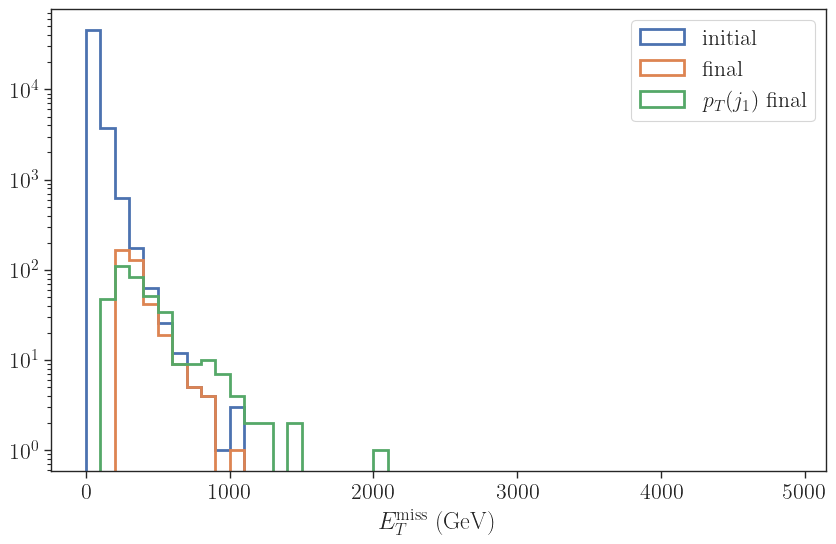

In [13]:
fig = plt.figure(figsize=(10,6))
for label, pt in metIni.items():
    plt.hist(metIni[label],bins=np.arange(0.,5000.,100.),density=False,
             histtype='step',linewidth=2,label='initial')
    plt.hist(metFinal[label],bins=np.arange(0.,5000.,100.),density=False,
             histtype='step',linewidth=2,label='final')
    plt.hist(ptjFinal[label],bins=np.arange(0.,5000.,100.),density=False,
             histtype='step',linewidth=2,label=r'$p_{T}(j_{1})$ final')
    
        
plt.yscale('log')
# plt.ylim(1e-4,1e0)
plt.xlabel(r'$E^{\rm miss}_{T}$ (GeV)')
# plt.ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb)')
# plt.xlim(0,1000)
plt.legend()
# plt.title(r'$m_{G} = %1.2f \pm %1.2f$' %(np.mean(mG),np.std(mG)))
plt.show()

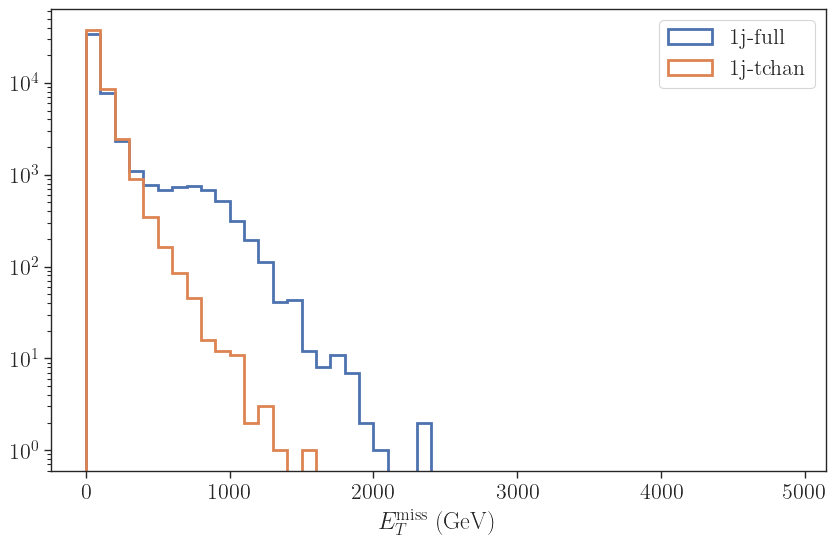

In [9]:
fig = plt.figure(figsize=(10,6))
for label, pt in genMet.items():
    plt.hist(met[label],bins=np.arange(0.,5000.,100.),density=False,
             histtype='step',linewidth=2,label=label)
    
        
plt.yscale('log')
# plt.ylim(1e-4,1e0)
plt.xlabel(r'$E^{\rm miss}_{T}$ (GeV)')
# plt.ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb)')
# plt.xlim(0,1000)
plt.legend()
# plt.title(r'$m_{G} = %1.2f \pm %1.2f$' %(np.mean(mG),np.std(mG)))
plt.show()